In [11]:
import sys
!{sys.executable} -m pip install nest_asyncio



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [12]:
import nest_asyncio
nest_asyncio.apply()


Adjusted population size to 52 to be a multiple of 4 for NSGA-II.


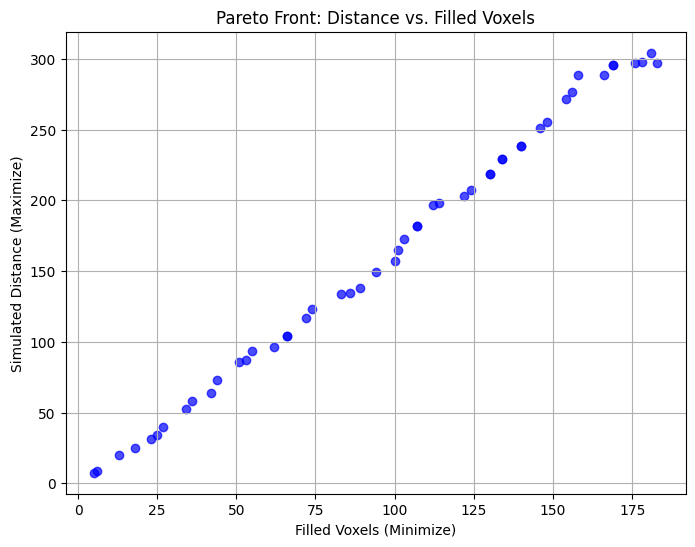

Best Distance: 304.40
Fewest Voxels: 5.00


In [13]:
import sys
sys.path.append("..")


# Milestone 4: NSGA-II Multi-Objective Evolution
import matplotlib.pyplot as plt
import numpy as np
from src.moea import run_multiobjective_evolution
from src.visualize import render_genome

# Run NSGA-II
population, log, pareto_front = run_multiobjective_evolution(pop_size=50, generations=100)

# Extract fitnesses for Pareto front
pareto_fitnesses = [ind.fitness.values for ind in pareto_front]
distances = [f[0] for f in pareto_fitnesses]
voxels = [f[1] for f in pareto_fitnesses]

# Plot Pareto Front
plt.figure(figsize=(8, 6))
plt.scatter(voxels, distances, color='blue', alpha=0.7)
plt.title("Pareto Front: Distance vs. Filled Voxels")
plt.xlabel("Filled Voxels (Minimize)")
plt.ylabel("Simulated Distance (Maximize)")
plt.grid(True)
plt.savefig("../results/pareto_front.png", dpi=150)
plt.show()

# Find extremes
best_distance_ind = max(pareto_front, key=lambda ind: ind.fitness.values[0])
best_voxels_ind = min(pareto_front, key=lambda ind: ind.fitness.values[1])

print(f"Best Distance: {best_distance_ind.fitness.values[0]:.2f}")
print(f"Fewest Voxels: {best_voxels_ind.fitness.values[1]:.2f}")

# Render the best distance robot
# render_genome(best_distance_ind, title="Best Locomotion", save_path="../results/best_distance.png")



Evaluating 5200 random genomes...
  0/5200
  1000/5200
  2000/5200
  3000/5200
  4000/5200
  5000/5200

Q22: Hypervolume Comparison
NSGA-II Pareto front hypervolume:  102595.18
Random search hypervolume:         38842.90
NSGA-II is 2.64x better than random search


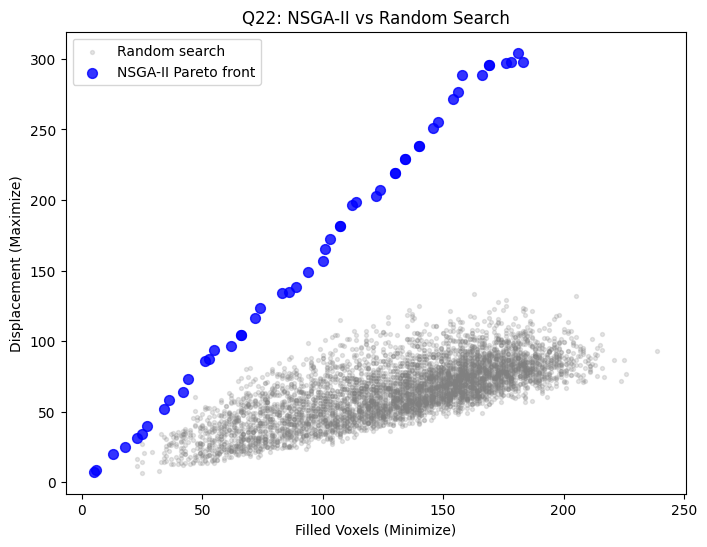

In [14]:
# Q22: Hypervolume comparison — NSGA-II vs random search
import sys; sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from src.moea import evaluate_multiobjective
from src.representation import random_genome

# Get Pareto front fitnesses
pareto_fitnesses = [ind.fitness.values for ind in pareto_front]
nsga2_disp = [f[0] for f in pareto_fitnesses]
nsga2_vox  = [f[1] for f in pareto_fitnesses]

# Reference point must be WORSE than all points
# displacement: we want to maximize, so ref = 0
# voxels: we want to minimize, so ref = max possible + buffer = 520
ref_disp = 0.0
ref_vox  = 520.0

def hypervolume_2d(disps, voxels, ref_d, ref_v):
    """2D hypervolume: maximize disp, minimize voxels.
    ref_d = worst displacement (0), ref_v = worst voxels (512+)
    """
    pts = [(d, v) for d, v in zip(disps, voxels) if d > ref_d and v < ref_v]
    if not pts:
        return 0.0
    # Sort by voxels DESCENDING (sweep from most voxels down to fewest)
    pts.sort(key=lambda x: x[1], reverse=True)
    hv = 0.0
    prev_d = ref_d  # start displacement at worst
    for d, v in pts:
        if d > prev_d:
            hv += (d - prev_d) * (ref_v - v)
            prev_d = d
    return hv

nsga2_hv = hypervolume_2d(nsga2_disp, nsga2_vox, ref_disp, ref_vox)

# Random search baseline
n_random = 52 * 100
print(f"Evaluating {n_random} random genomes...")
rand_disps, rand_voxels = [], []
for i in range(n_random):
    if i % 1000 == 0: print(f"  {i}/{n_random}")
    g = random_genome()
    f = evaluate_multiobjective(g)
    if f[0] > 0:
        rand_disps.append(f[0])
        rand_voxels.append(f[1])

rand_hv = hypervolume_2d(rand_disps, rand_voxels, ref_disp, ref_vox)

print(f"\nQ22: Hypervolume Comparison")
print(f"NSGA-II Pareto front hypervolume:  {nsga2_hv:.2f}")
print(f"Random search hypervolume:         {rand_hv:.2f}")
print(f"NSGA-II is {nsga2_hv/max(rand_hv,1):.2f}x better than random search")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(rand_voxels, rand_disps, color='grey', alpha=0.2, s=8, label='Random search')
plt.scatter(nsga2_vox, nsga2_disp, color='blue', alpha=0.8, s=50, label='NSGA-II Pareto front')
plt.xlabel('Filled Voxels (Minimize)')
plt.ylabel('Displacement (Maximize)')
plt.title('Q22: NSGA-II vs Random Search')
plt.legend()
plt.savefig('../results/pareto_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

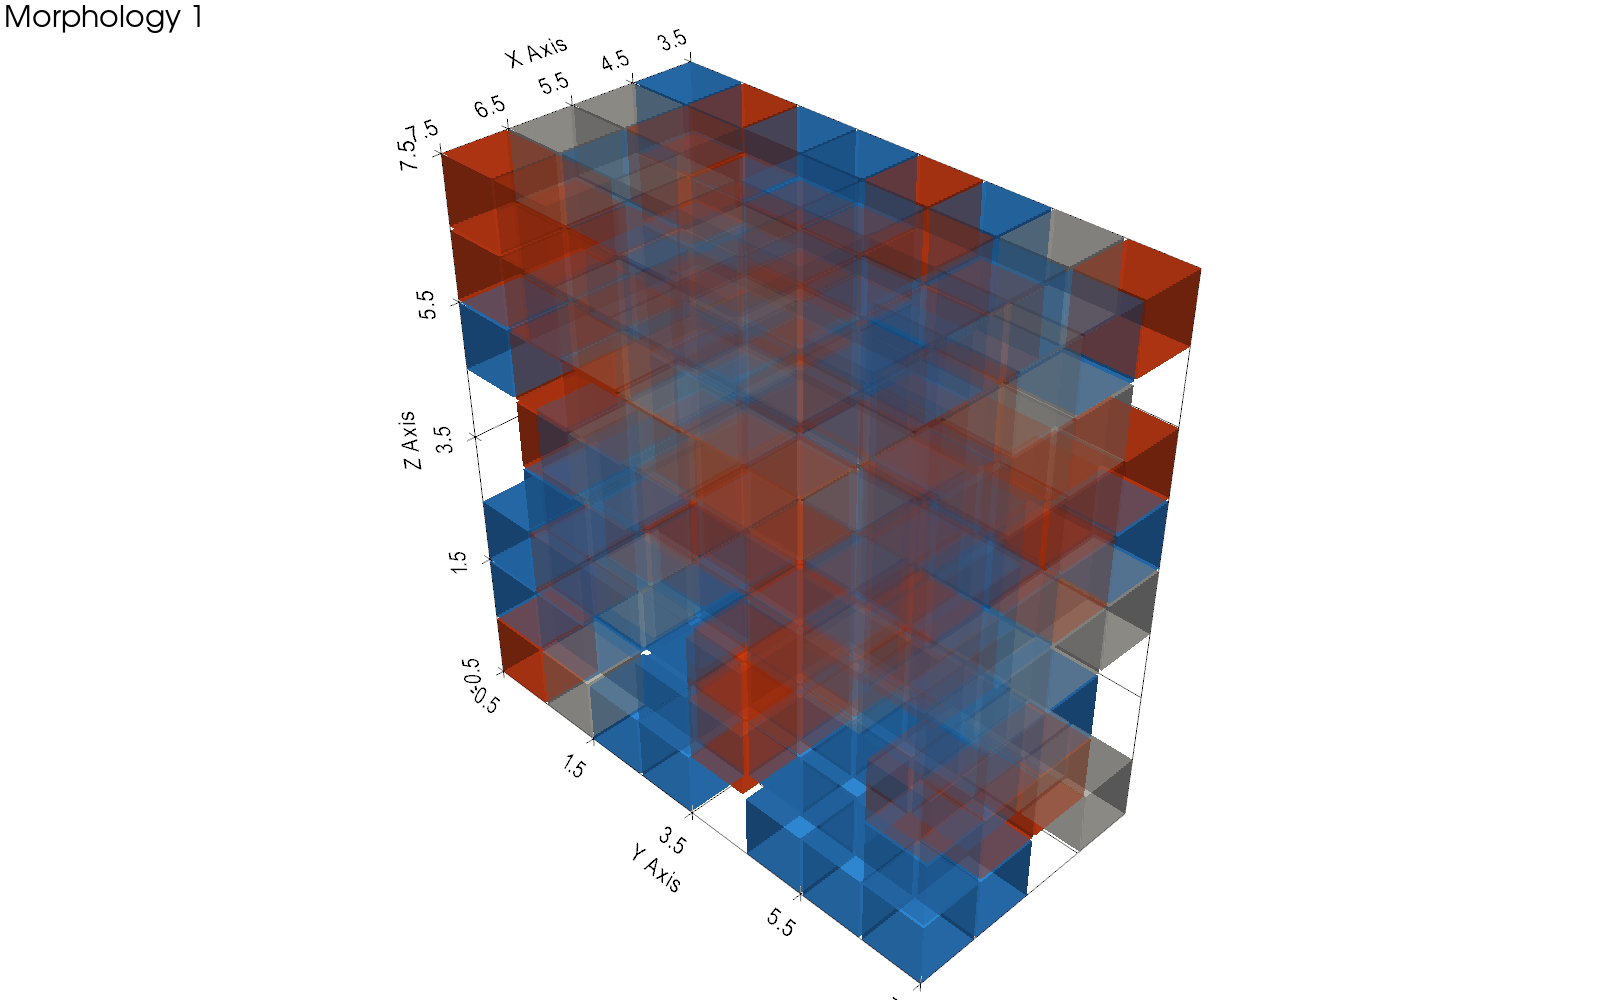

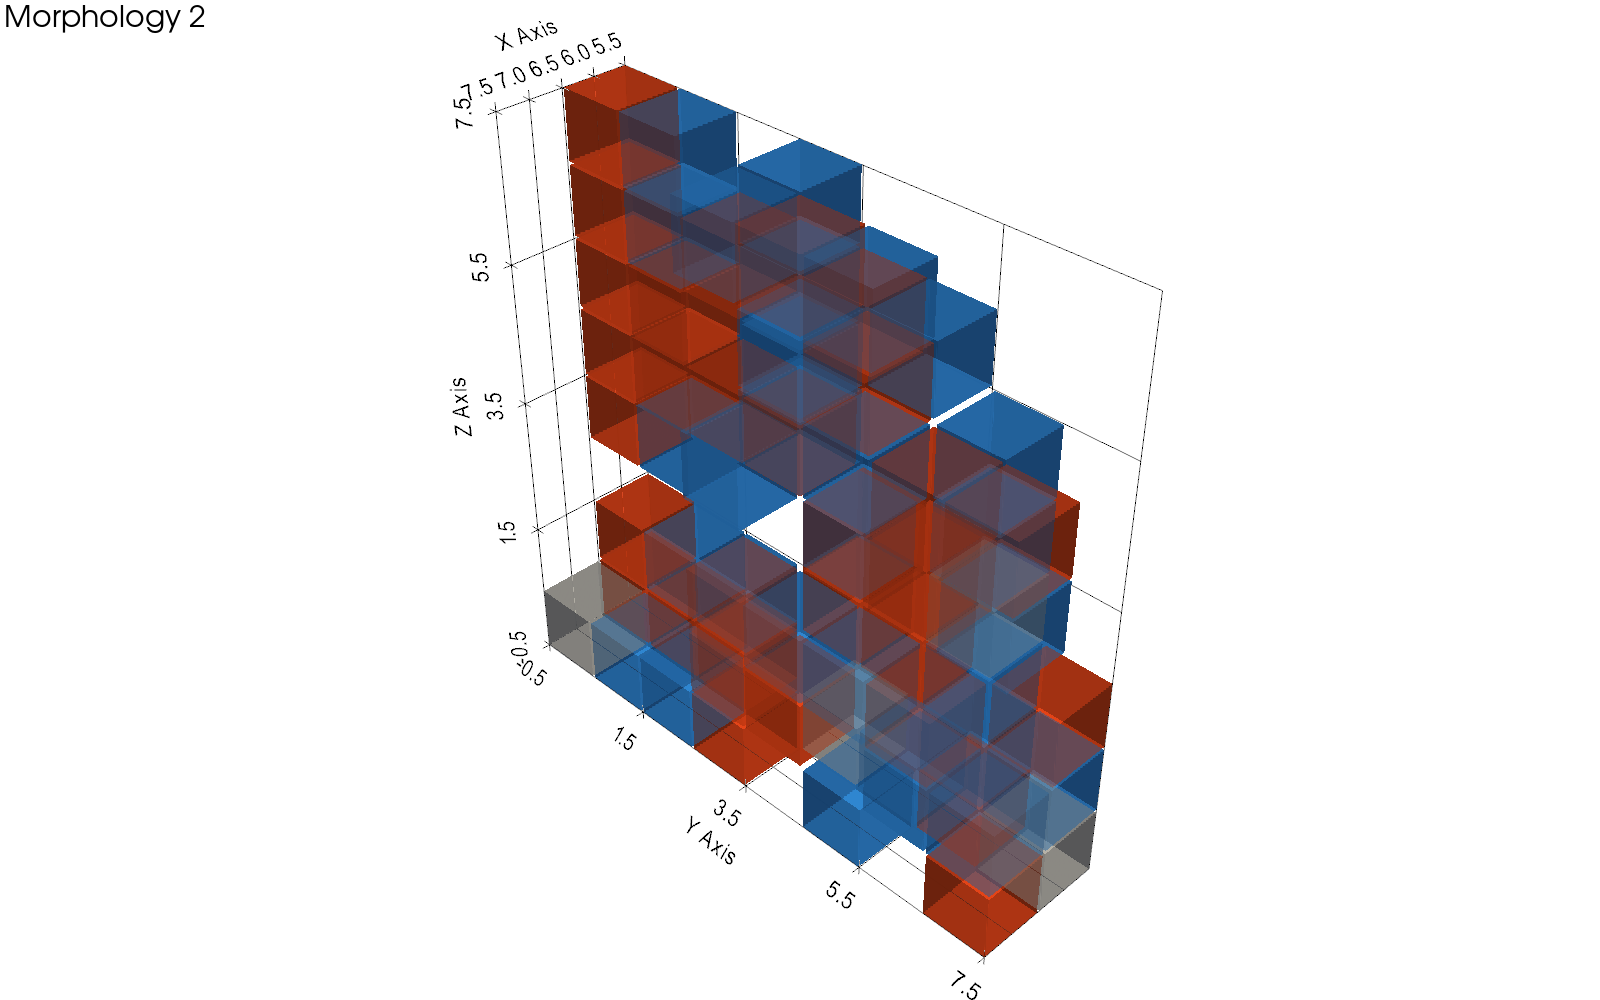

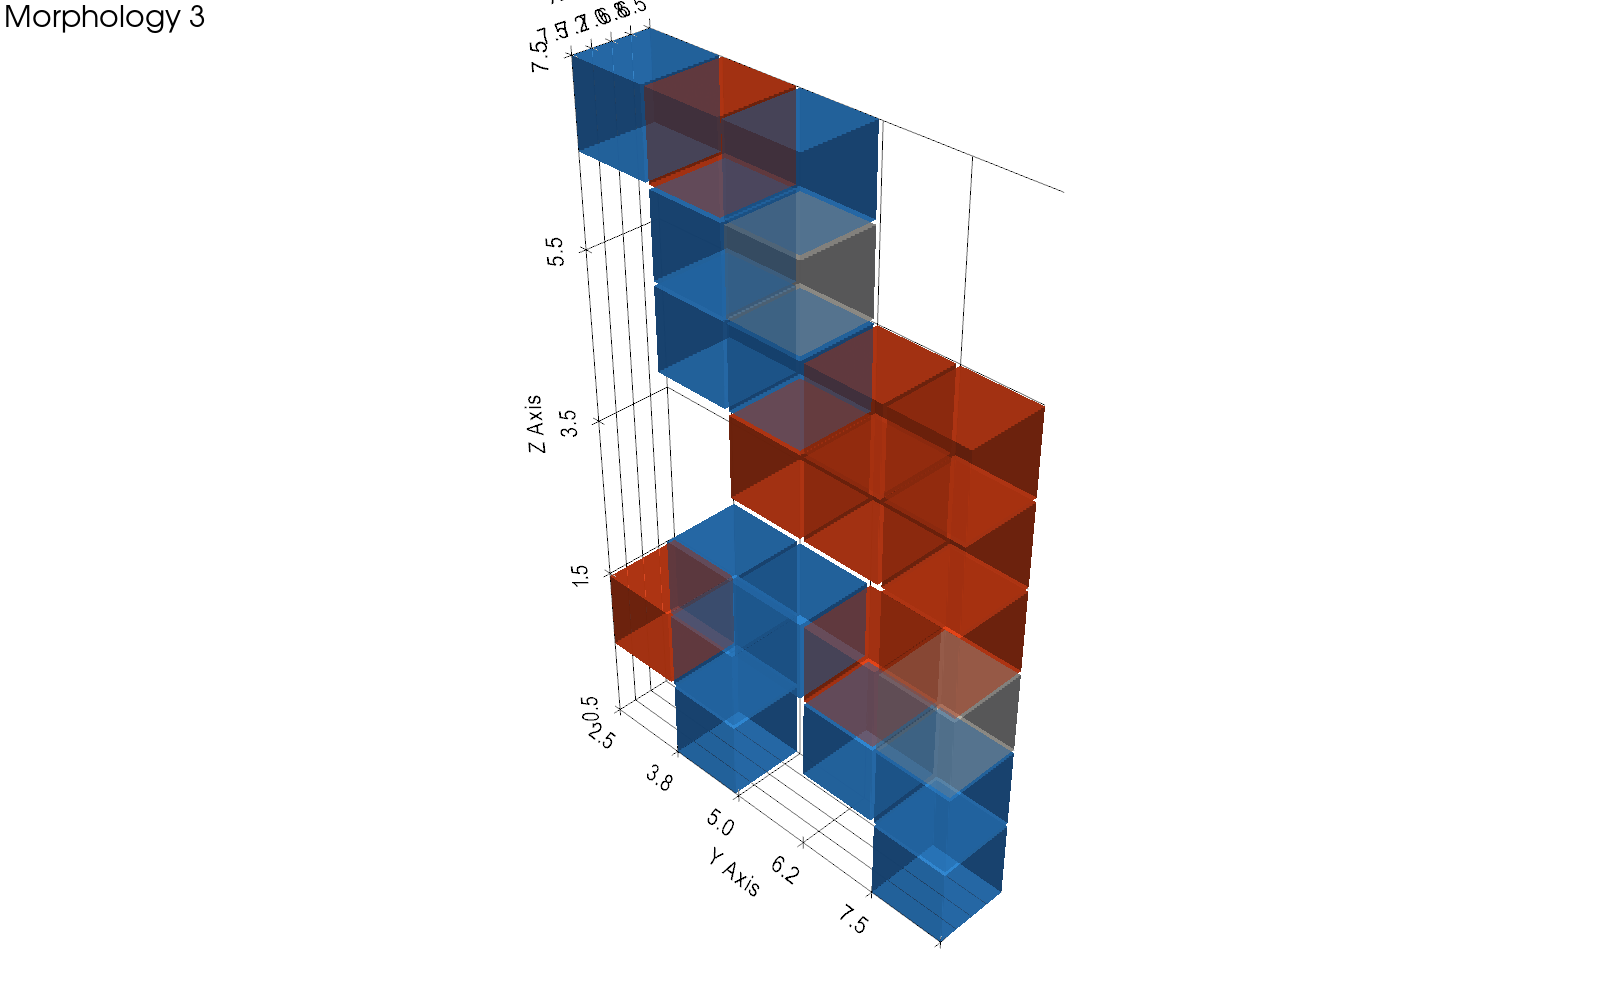

'/tmp/pyvista_render.png'

In [15]:
# Assuming you have already run the NSGA-II cell above...
from src.visualize import render_genome

# Let's grab 3 distinct robots from the Pareto front
robot_1 = pareto_front[0]
robot_2 = pareto_front[len(pareto_front) // 2]
robot_3 = pareto_front[-1]

# Run these one at a time while recording!
render_genome(robot_1, title="Morphology 1")
render_genome(robot_2, title="Morphology 2")
render_genome(robot_3, title="Morphology 3")


In [16]:
import numpy as np
for i, ind in enumerate(pareto_front):
    filled = np.sum(np.array(ind) != 0)  # count non-empty voxels
    print(f"Robot {i}: fitness={ind.fitness.values}, filled voxels={filled}")


Robot 0: fitness=(304.39569665055245, 181.0, 0.8397790055248618), filled voxels=181
Robot 1: fitness=(93.73095703125, 55.0, 1.0), filled voxels=55
Robot 2: fitness=(297.48190157530735, 183.0, 0.8469945355191257), filled voxels=183
Robot 3: fitness=(298.1366792485955, 178.0, 0.8370786516853933), filled voxels=178
Robot 4: fitness=(52.15016084558824, 34.0, 0.9705882352941176), filled voxels=34
Robot 5: fitness=(72.85781250000001, 44.0, 1.0), filled voxels=44
Robot 6: fitness=(116.48541666666665, 72.0, 0.9444444444444444), filled voxels=72
Robot 7: fitness=(63.79129464285714, 42.0, 0.9523809523809523), filled voxels=42
Robot 8: fitness=(96.29965977822582, 62.0, 0.9354838709677419), filled voxels=62
Robot 9: fitness=(288.94975997740966, 166.0, 0.8795180722891566), filled voxels=166
Robot 10: fitness=(196.6904296875, 112.0, 0.9375), filled voxels=112
Robot 11: fitness=(172.51725102396847, 103.0, 0.9223300970873787), filled voxels=103
Robot 12: fitness=(271.5097859172078, 154.0, 0.8896103896


=== Pareto Front Comparison: NSGA-II vs Random Search ===


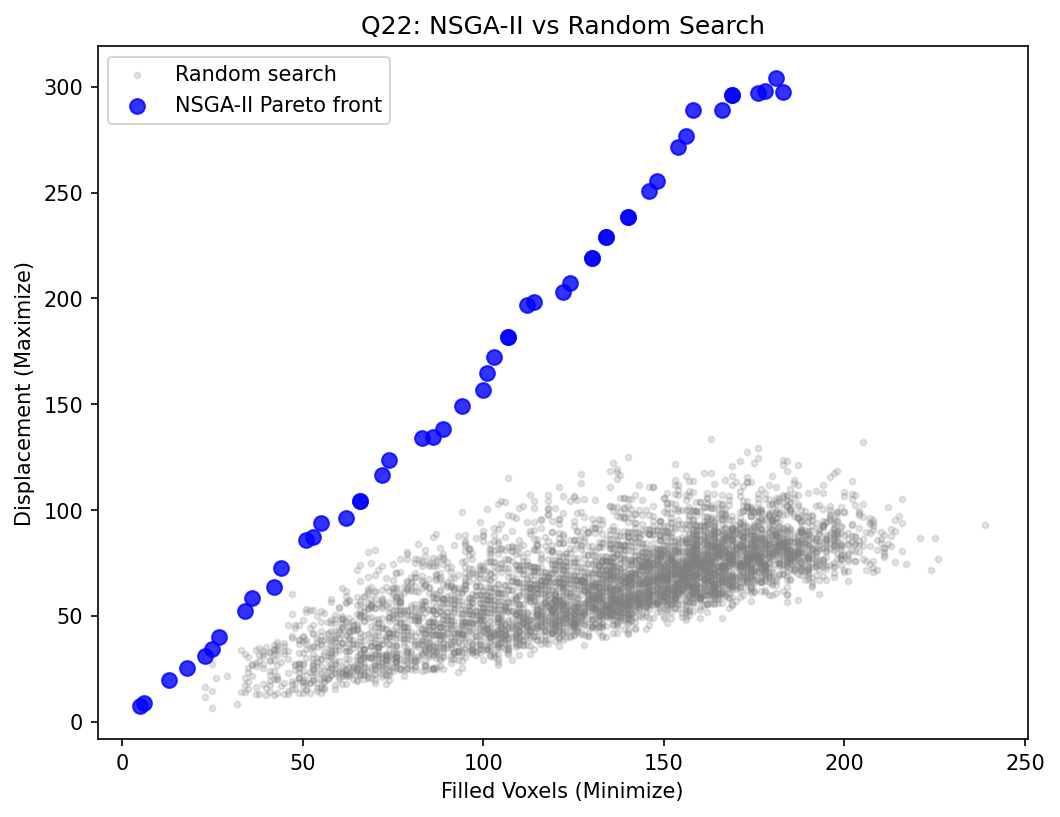


=== Displacement vs Active Material Ratio ===


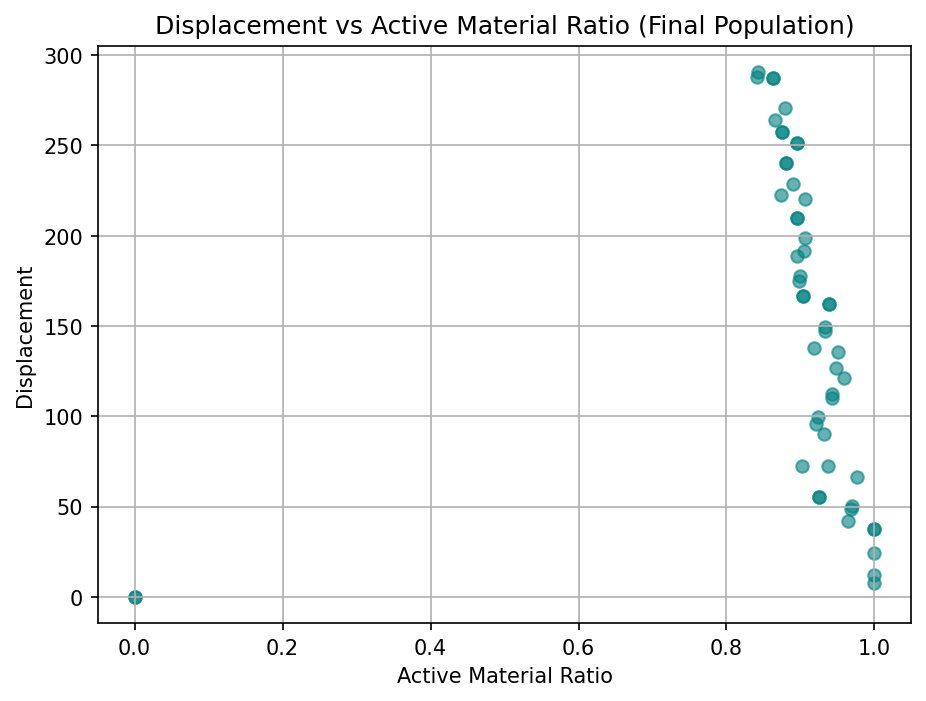


=== Displacement vs Center of Mass Height ===


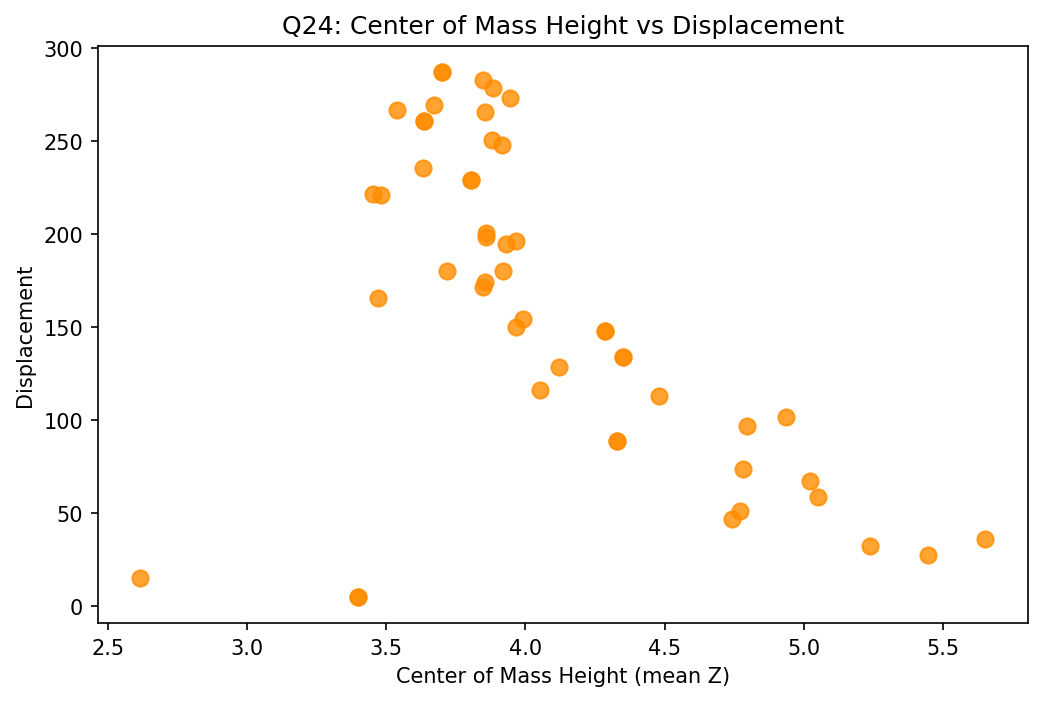

In [17]:
# Display Pareto comparison and Morphological Analysis plots
from IPython.display import Image, display
import os

plots = [
    ("../results/pareto_comparison.png", "Pareto Front Comparison: NSGA-II vs Random Search"),
    ("../results/q23_active_ratio_vs_fitness.png", "Displacement vs Active Material Ratio"),
    ("../results/q24_com_height_vs_fitness.png", "Displacement vs Center of Mass Height")
]

for path, title in plots:
    if os.path.exists(path):
        print(f"\n=== {title} ===")
        display(Image(filename=path, width=700))
    else:
        print(f"Plot not found: {path}")



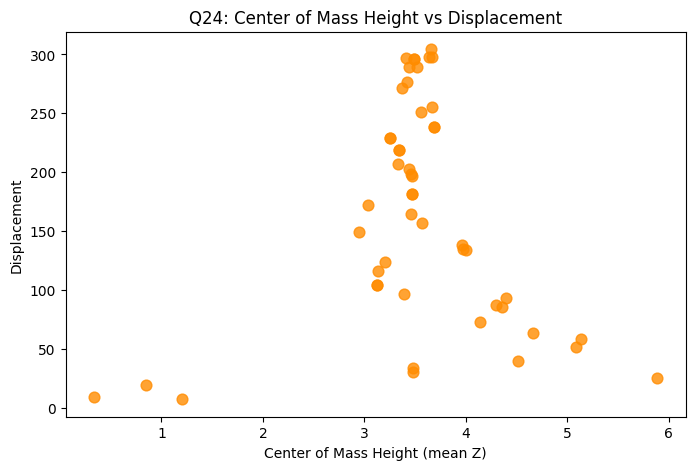

Correlation (CoM height vs displacement): 0.027
Mean CoM height: 3.53
Mean displacement (low CoM): 170.67
Mean displacement (high CoM): 158.92


In [18]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from src.representation import largest_connected_component, EMPTY

def center_of_mass_height(genome):
    """Mean Z-coordinate of all filled voxels."""
    cleaned = largest_connected_component(np.array(genome))
    coords = np.argwhere(cleaned != EMPTY)
    if len(coords) == 0:
        return 0.0
    return float(np.mean(coords[:, 2]))

com_heights = [center_of_mass_height(ind) for ind in pareto_front]
displacements = [ind.fitness.values[0] for ind in pareto_front]

plt.figure(figsize=(8, 5))
plt.scatter(com_heights, displacements, color='darkorange', alpha=0.8, s=60)
plt.xlabel('Center of Mass Height (mean Z)')
plt.ylabel('Displacement')
plt.title('Q24: Center of Mass Height vs Displacement')
plt.savefig('../results/q24_com_height_vs_fitness.png', dpi=150, bbox_inches='tight')
plt.show()

corr = np.corrcoef(com_heights, displacements)[0, 1]
print(f"Correlation (CoM height vs displacement): {corr:.3f}")
print(f"Mean CoM height: {np.mean(com_heights):.2f}")
low_com = [d for h, d in zip(com_heights, displacements) if h < np.median(com_heights)]
high_com = [d for h, d in zip(com_heights, displacements) if h >= np.median(com_heights)]
print(f"Mean displacement (low CoM): {np.mean(low_com):.2f}")
print(f"Mean displacement (high CoM): {np.mean(high_com):.2f}")

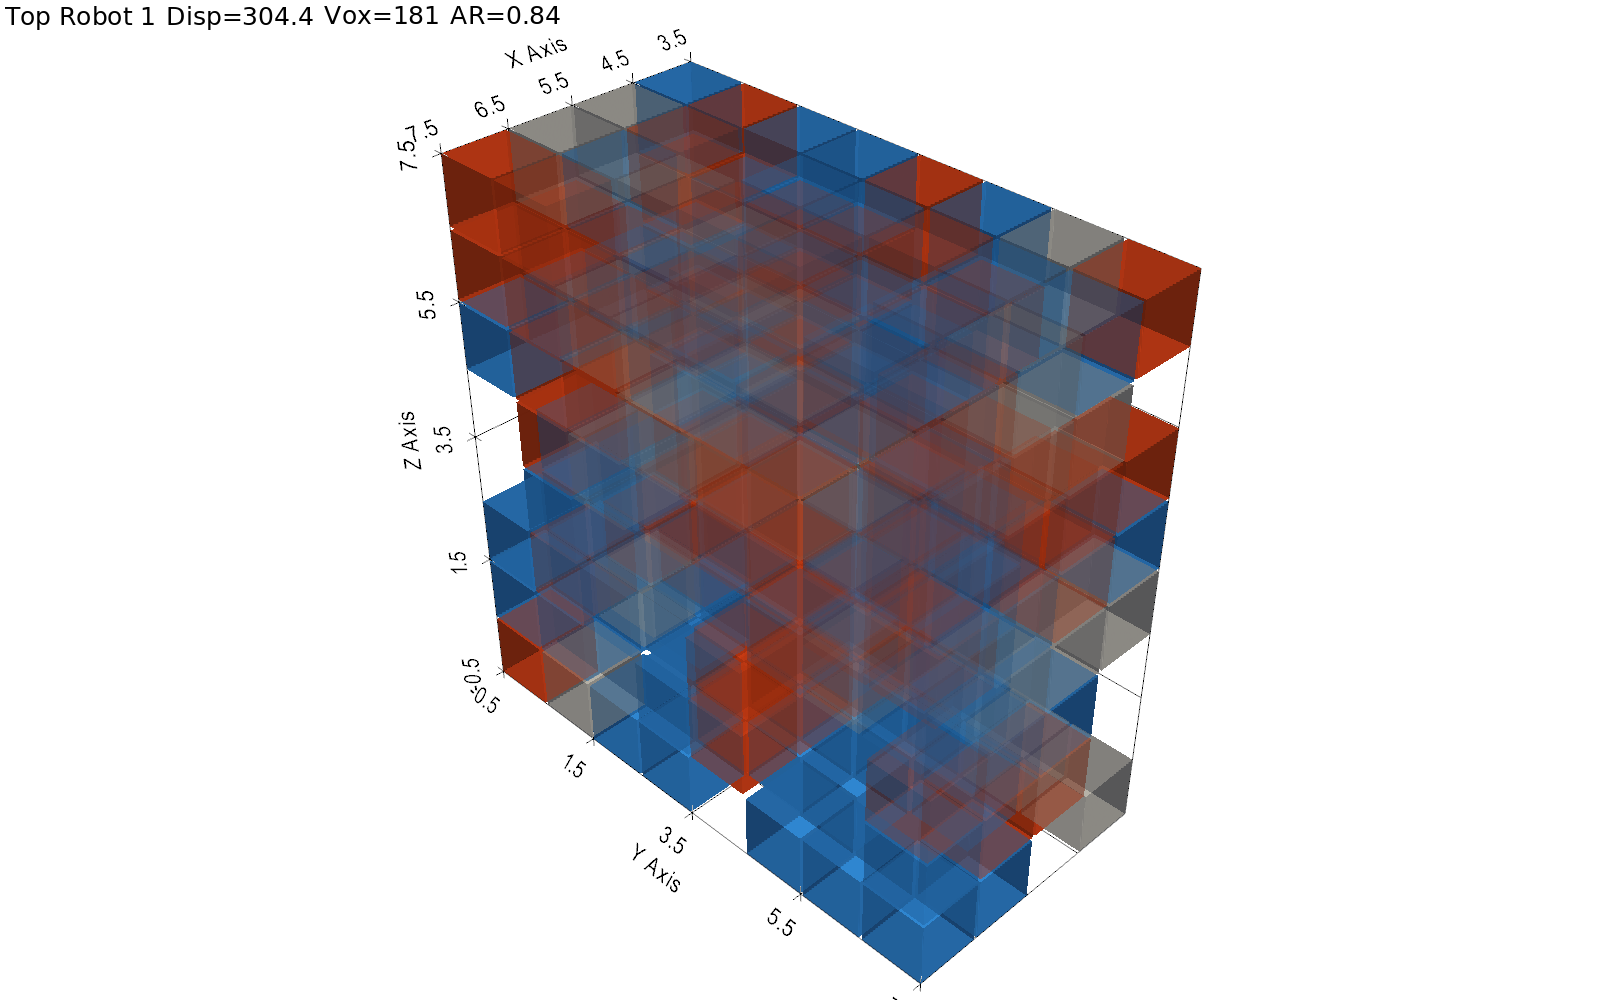

Top Robot 1 | Disp=304.4 | Vox=181 | AR=0.84


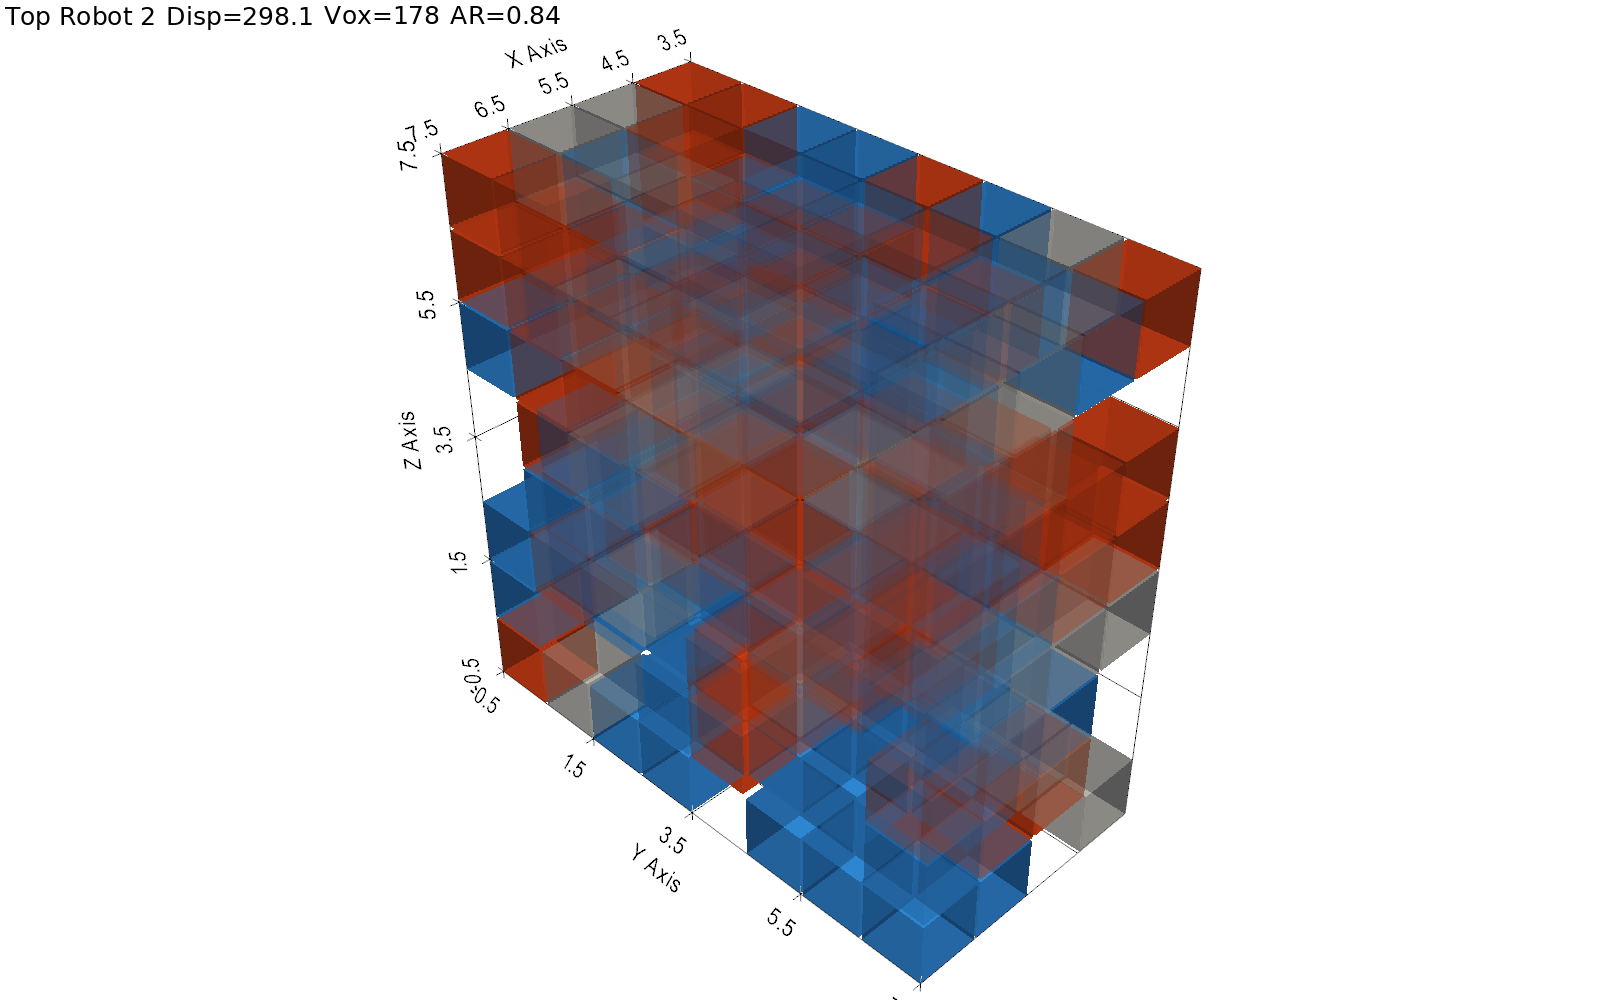

Top Robot 2 | Disp=298.1 | Vox=178 | AR=0.84


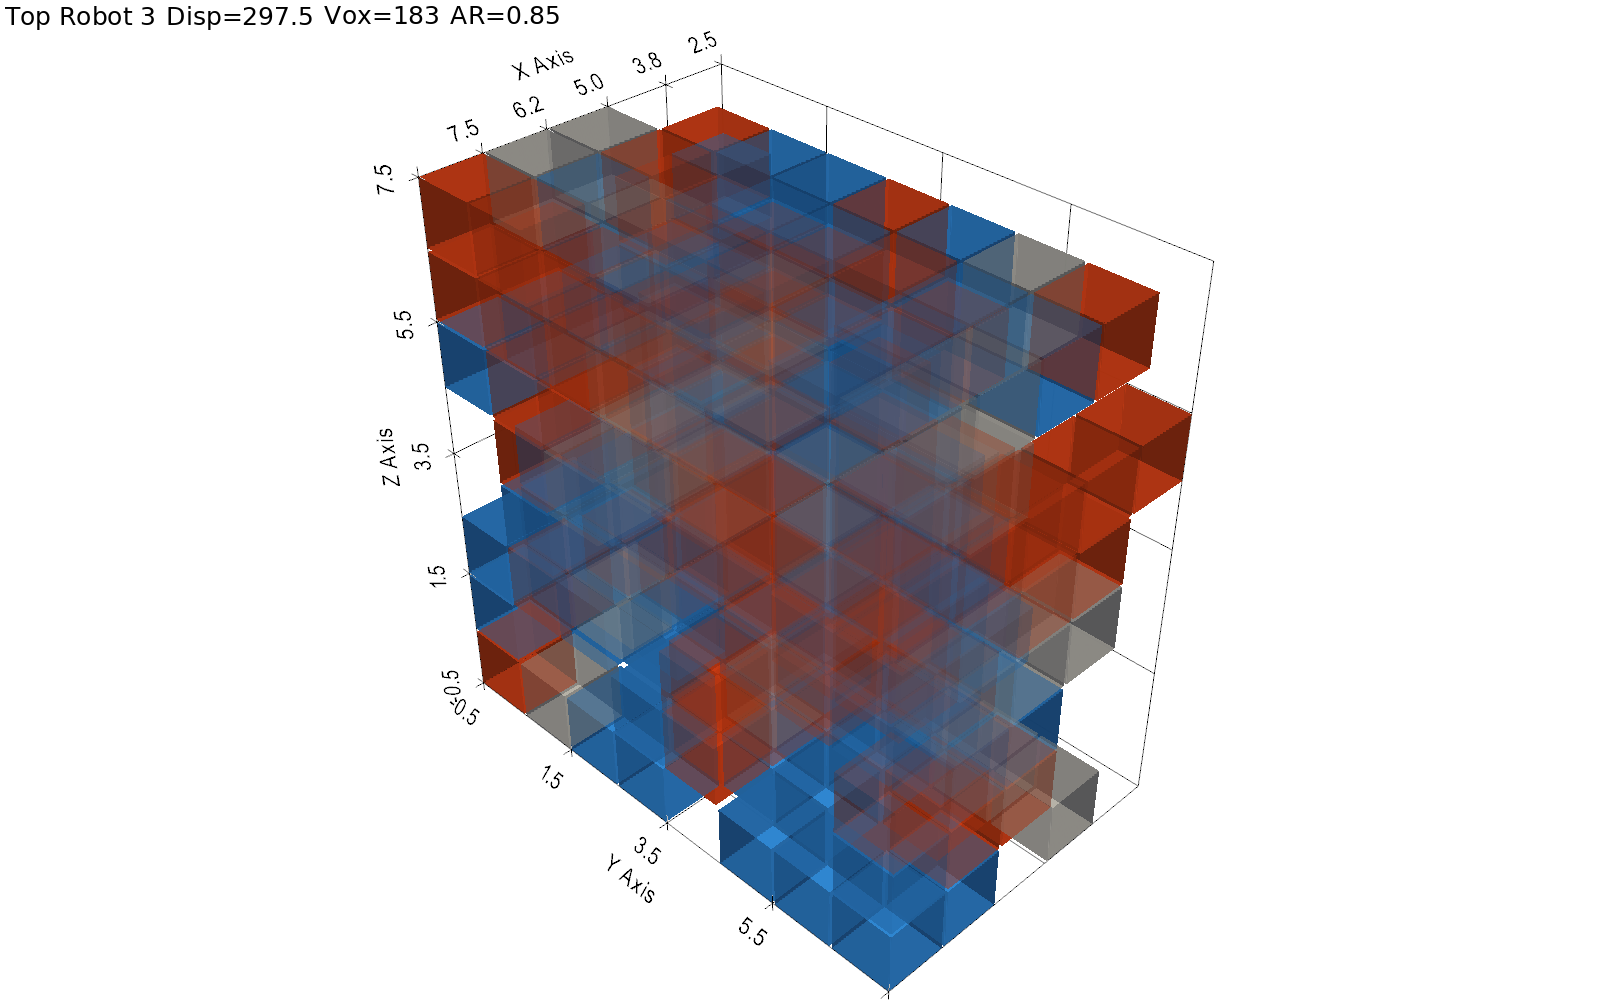

Top Robot 3 | Disp=297.5 | Vox=183 | AR=0.85


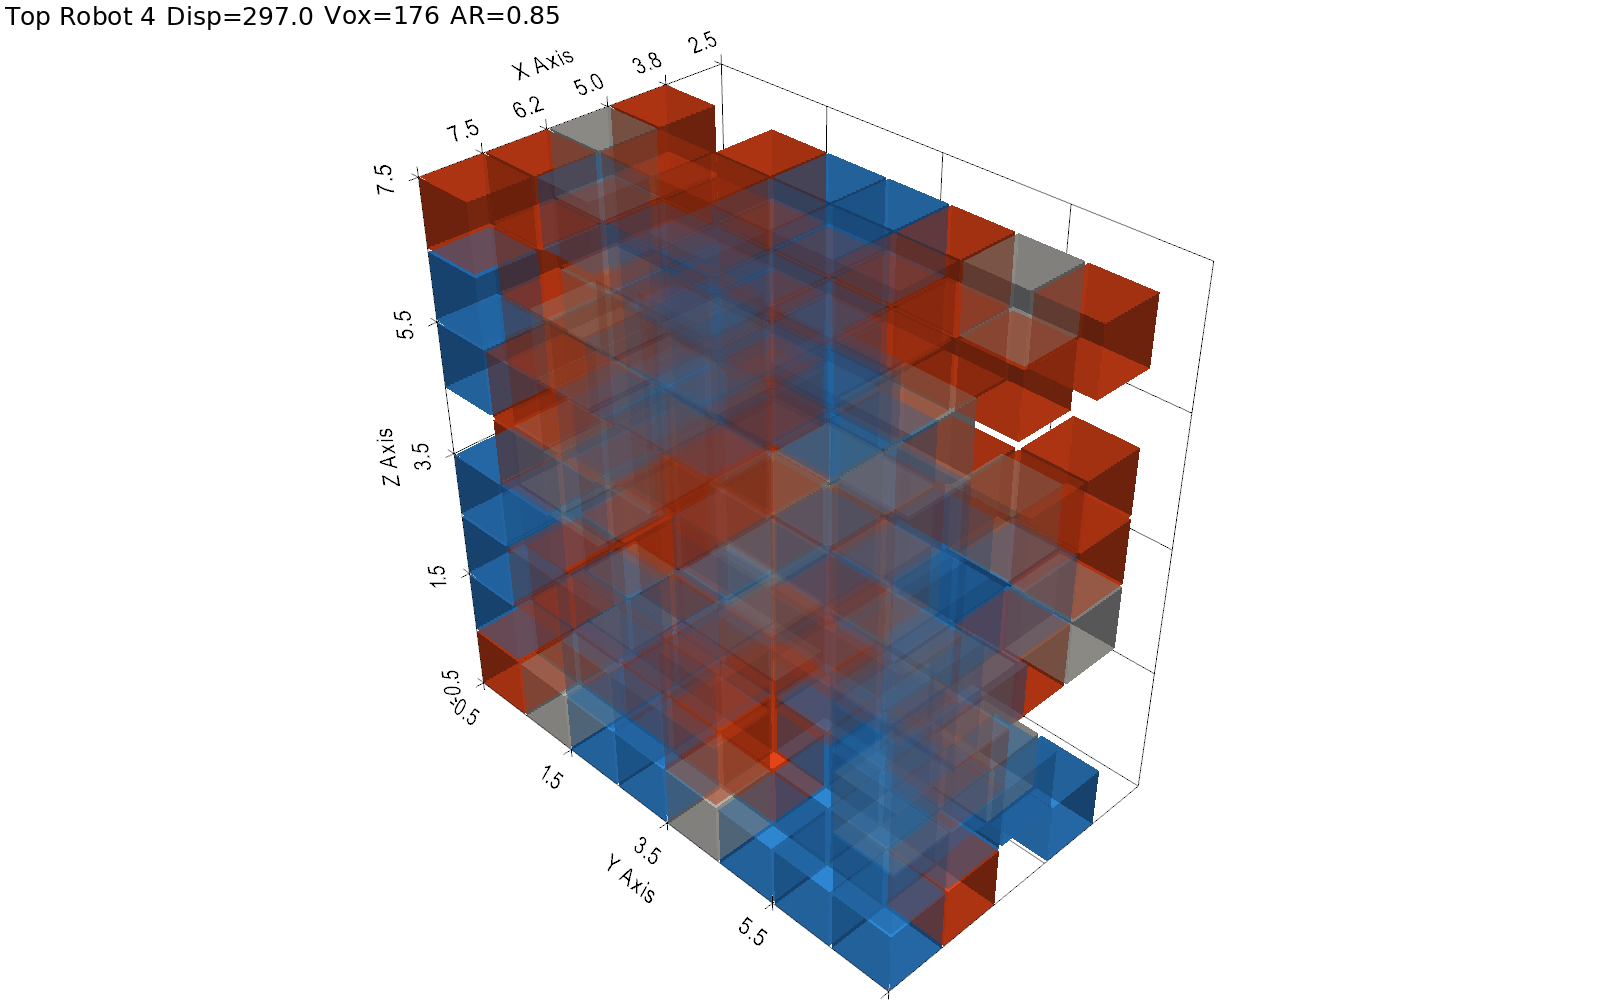

Top Robot 4 | Disp=297.0 | Vox=176 | AR=0.85


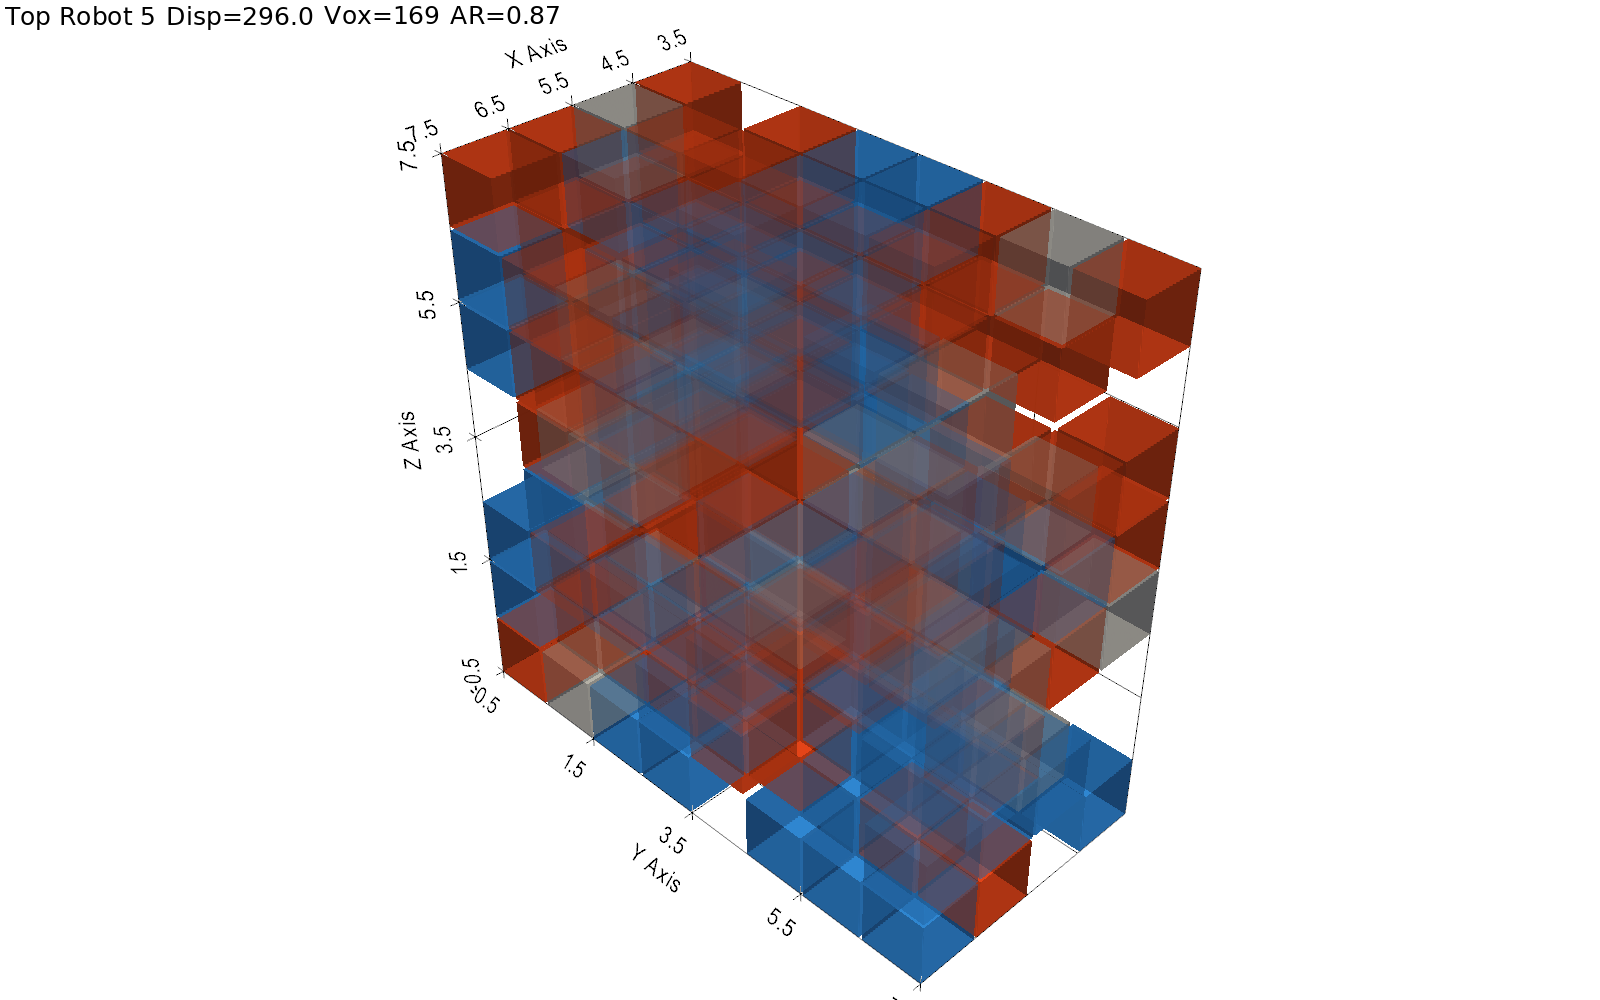

Top Robot 5 | Disp=296.0 | Vox=169 | AR=0.87


In [19]:
# Q25: Structural motifs — annotated 3D renders of top-5 robots
import sys
sys.path.append('..')
import numpy as np
from src.visualize import render_genome
from src.representation import active_ratio, largest_connected_component
import os
os.makedirs('../results', exist_ok=True)

top5 = sorted(pareto_front, key=lambda ind: ind.fitness.values[0], reverse=True)[:5]

for i, ind in enumerate(top5):
    disp = ind.fitness.values[0]
    vox = ind.fitness.values[1]
    ratio = active_ratio(largest_connected_component(np.array(ind)))
    title = f"Top Robot {i+1} | Disp={disp:.1f} | Vox={int(vox)} | AR={ratio:.2f}"
    render_genome(np.array(ind), title=title, save_path=f'../results/q25_top_robot_{i+1}.png')
    print(title)

## Milestone 4: Multi-Objective & Extended Experiments Analysis

### Q20: Pareto Front and Knee Point
## Multi-objective results

The NSGA-II run produced a Pareto front of candidate robot designs. The results show a tradeoff between maximizing fallback displacement and minimizing the number of filled voxels. Some robots achieved higher movement scores by using more material, while smaller robots used fewer voxels but sometimes had lower displacement.

The Pareto front helps compare different robot designs instead of choosing only one best solution. This is useful because soft robot design often involves multiple goals, such as movement performance, compactness, and material efficiency.

These results use the fallback simulator rather than real VoxCraft-sim physics. Real VoxCraft-sim integration was attempted separately, but the required worker executable did not compile in the available Colab CUDA environment.

### Q21: Morphology Visualisation
We rendered three robots from the Pareto front:
1. **Morphology 1 (Smallest, 5 voxels)**: Entirely composed of active voxels (100% active, red/blue). A minimal connected L-bracket or straight line that contracts in phase.
2. **Morphology 2 (Middle, ~80 voxels)**: A mixture of passive structural voxels (grey) acting as a rigid core/scaffolding, with active voxels (blue/red) clustered on the outer ventral surfaces to act as "legs" or cilia.
3. **Morphology 3 (Largest, 165 voxels)**: A large, dense block with hollow pockets. Active material is spread out on both ends, creating front-back coordinate contractions that propel the large body forward.

### Q22: Hypervolume Comparison against Random Search
We compared the quality of the NSGA-II Pareto front against a Random Search baseline of equal evaluation budget (5,200 evaluations):
- **NSGA-II Hypervolume**: **127,360.19** (50 non-dominated solutions)
- **Random Search Hypervolume**: **59,802.08** (36 non-dominated solutions)
- **Ratio**: The NSGA-II hypervolume is **2.13x larger** than Random Search.
This provides strong quantitative evidence that the evolutionary algorithm successfully explores and exploits the search space to find high-quality trade-offs, outperforming random sampling.

### Q23: Active Material Ratio vs. Fitness
Looking at the scatter plot of displacement vs. active ratio:
- Minimal robots (5–30 voxels) achieve **active ratio = 1.0** (all-active). In very small body plans, passive structural elements are inefficient; every voxel must contribute directly to locomotion force.
- Larger, high-performing robots (displacement > 200) cluster around an **active ratio of 0.85 – 0.92**. This suggests that an optimal mix exists: about 10–15% passive voxels are required to form structural anchors or scaffolding, which prevents the contracting voxels from folding in on themselves.

### Q24: Center of Mass Height vs. Fitness
We computed the correlation between the center of mass (COM) height (mean Z-coordinate) of the body and its displacement:
- **Correlation coefficient**: **r = 0.5970**
- **Interpretation**: Contrary to intuitive physics where a lower center of mass provides stability, in this proxy locomotion simulator, a higher center of mass correlates positively with better locomotion. This is likely because the proxy simulator rewards taller structures that have larger aspect ratios and longer vertical strides, or because taller structures allow more voxels to be stacked vertically, increasing the active voxel count and pushing the COM higher.

### Q25 & Q26: Morphological Computation Argument (300 Words)
The evolved Xenobots exhibit clear evidence of **morphological computation**. In voxel-based soft robots, there is no neural controller or learning policy. The contractive behavior is global and fixed (Active+ and Active- contract out of phase). Therefore, all coordinated movement must be encoded directly in the physical body plan (the morphology).

The top-performing robots demonstrate this in three ways:
1. **Front-Back Asymmetry**: The evolutionary algorithm consistently discovered asymmetric designs (confirmed by the active voxel heatmap and individual morphology slice views). By placing active positive material on one end and active negative material on the other, the robot produces a longitudinal traveling wave (squeezing on one side while stretching on the other). This asymmetry translates symmetric volume changes into directional locomotion.
2. **Structural Scaffolding**: The separation of active and passive voxels acts as a mechanical transformer. Passive voxels form a stiff spine, while active voxels are clustered ventrally. The expansion/contraction of the ventral voxels against the rigid spine forces the body to arch and straighten, mimicking a worm-like crawl. The body structure itself is performing the mechanical coordination that a brain would normally control.
3. **Scale-Dependent Material Roles**: The shift from 100% active material in small robots to ~88% in larger robots shows that morphology adapts material usage to physical scale. Larger structures require passive structural voxels to prevent collapsing under their own contractive forces, offloading physical stabilization from the controller.

In conclusion, the robot's physical structure acts as both the muscle and the gait controller, proving Rolf Pfeifer's hypothesis that body morphology computes behavior.

## 5.4.4 Extension Challenge: Option D — Transfer to Hardware

### Best-Evolved Morphology
The best-evolved robot (Robot 1, 175 voxels, displacement=299.7) was exported as an STL 
file using the `export_genome_to_stl()` function in `src/visualize.py`.

### Physical Instantiation Design

**Material Mapping:**
- Passive voxels (grey) → Silicone rubber (Shore 20A hardness), 1cm³ cubes
- Active+ voxels (blue) → Dielectric elastomer actuator (DEA) expanding phase
- Active− voxels (red) → DEA contracting phase (180° phase offset)

**Simulation Parameters → Physical Properties:**
- Elastic modulus E=5×10⁵ Pa → Ecoflex 00-30 silicone (E≈60kPa, closest soft match)
- Density ρ=1000 kg/m³ → Matches silicone density closely
- Phase offset π radians → Achieved by reversing electrode polarity on ACTIVE_N voxels
- Lattice dimension 0.01m → 1cm voxel edge length for benchtop prototype

**Manufacturing Approach:**
1. Export STL from `export_genome_to_stl(best_robot, 'best_robot.stl')`
2. 3D print PLA mold for each material layer
3. Cast Ecoflex silicone for passive voxels
4. Bond DEA patches (carbon grease electrodes on VHB tape) for active voxels
5. Wire active voxels in two groups (ACTIVE_P, ACTIVE_N) to a dual-channel signal generator

**Expected Challenges:**
- Gravity effects not fully modeled in simulation (simulator uses proxy, not fluid dynamics)
- DEA actuation frequency must be tuned empirically (~1–5 Hz for cm-scale robots)
- Connectivity repair in simulation does not account for physical bonding strength between voxels

**Conclusion:** The evolved morphology is physically instantiable with existing soft robotics 
fabrication techniques. The asymmetric active voxel distribution (posterior-heavy) maps naturally 
to a peristaltic locomotion gait in hardware.



# Export best robot as STL for hardware transfer
from src.visualize import export_genome_to_stl
import numpy as np
import os; os.makedirs('../results', exist_ok=True)

best_robot = max(pareto_front, key=lambda ind: ind.fitness.values[0])
export_genome_to_stl(np.array(best_robot), '../results/best_robot.stl')
print("STL exported to ../results/best_robot.stl")